In [10]:
#Charger les données
from pathlib import Path
import pandas as pd

DATA = Path("../data/processed")

jobs = pd.read_csv(DATA/"clean_jobs.csv")

jobs.head()

,job_title,description,company,location,salary,description_clean,skills,skills_count,skills_text
0,marketing coordinator,Job descriptionA leading real estate firm in N...,Corcoran Sawyer Smith,"Princeton, NJ",38480.0,job descriptiona leading real estate firm in n...,[],0,NaN
1,mental health therapist/counselor,"At Aspen Therapy and Wellness , we are committ...",unknown,"Fort Collins, CO",83200.0,"at aspen therapy and wellness , we are committ...",[],0,NaN
2,assitant restaurant manager,The National Exemplar is accepting application...,The National Exemplar,"Cincinnati, OH",55000.0,the national exemplar is accepting application...,[],0,NaN
3,senior elder law / trusts and estates associat...,Senior Associate Attorney - Elder Law / Trusts...,"Abrams Fensterman, LLP","New Hyde Park, NY",157500.0,senior associate attorney - elder law / trusts...,[],0,NaN
4,service technician,Looking for HVAC service tech with experience ...,unknown,"Burlington, IA",70000.0,looking for hvac service tech with experience ...,[],0,NaN


In [11]:
#Vérifier le dataset

In [12]:
jobs.shape

(48563, 9)

In [13]:
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48563 entries, 0 to 48562
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   job_title          48563 non-null  object 
 1   description        48561 non-null  object 
 2   company            48563 non-null  object 
 3   location           48563 non-null  object 
 4   salary             14431 non-null  float64
 5   description_clean  48556 non-null  object 
 6   skills             48563 non-null  object 
 7   skills_count       48563 non-null  int64  
 8   skills_text        14179 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 3.3+ MB


In [14]:
jobs.describe(include="all")

,job_title,description,company,location,salary,description_clean,skills,skills_count,skills_text
count,48563,48561,48563,48563,1.443100e+04,48556,48563,48563.000000,14179
unique,30756,44387,13353,5713,NaN,44289,2266,NaN,2265
top,sales manager,Position Summary: Our Sales Manager has managi...,Liberty Healthcare and Rehabilitation Services,United States,NaN,position summary: our sales manager has managi...,[],NaN,excel
freq,336,242,1059,3265,NaN,243,34384,NaN,5425
mean,NaN,NaN,NaN,NaN,1.857899e+05,NaN,NaN,0.591520,NaN
std,NaN,NaN,NaN,NaN,5.435239e+06,NaN,NaN,1.425786,NaN
min,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,0.000000,NaN
25%,NaN,NaN,NaN,NaN,5.200000e+04,NaN,NaN,0.000000,NaN
50%,NaN,NaN,NaN,NaN,8.112000e+04,NaN,NaN,0.000000,NaN
75%,NaN,NaN,NaN,NaN,1.248000e+05,NaN,NaN,1.000000,NaN


In [15]:
#Valeurs manquantes
jobs.isnull().sum().sort_values(ascending=False)

skills_text          34384
salary               34132
description_clean        7
description              2
job_title                0
location                 0
company                  0
skills                   0
skills_count             0
dtype: int64

In [8]:
#Top 20 métiers
top_jobs = jobs.job_title.value_counts().head(20)

top_jobs

job_title
sales manager                                   336
project manager                                 154
receptionist                                    142
assistant store manager                         132
registered nurse - rn - ltac                    122
senior accountant                               110
administrative assistant                        106
executive assistant                              97
salesperson                                      96
customer service representative                  94
account executive                                93
staff accountant                                 78
package handler - part time (warehouse like)     75
controller                                       73
associate attorney                               71
registered nurse                                 70
senior software engineer                         69
us experienced financial advisor                 69
store manager                                    68
sa

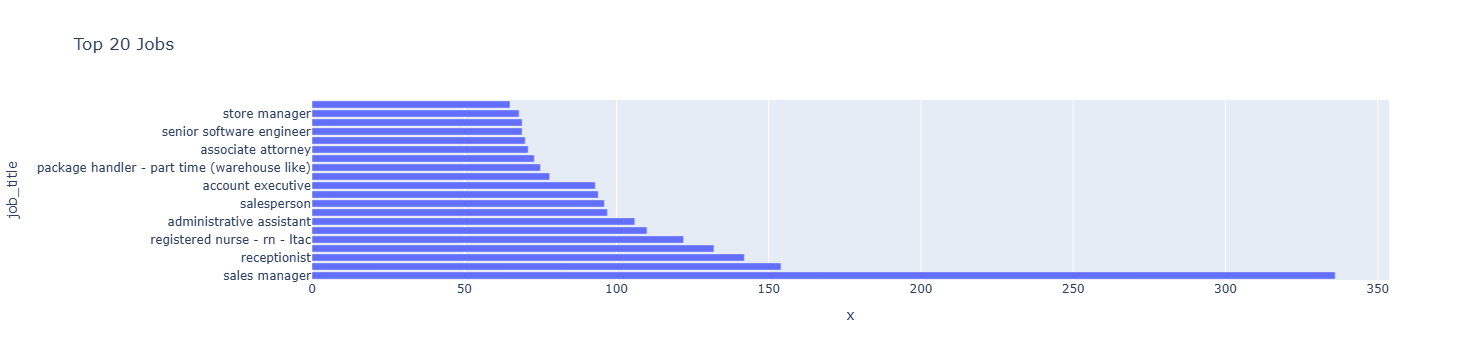

In [9]:
import plotly.express as px

fig = px.bar(
    top_jobs,
    x=top_jobs.values,
    y=top_jobs.index,
    orientation="h",
    title="Top 20 Jobs"
)

fig.show()

In [16]:
#Top compétences
skills = (
    jobs.skills_text
    .fillna("")
    .str.split(", ")
    .explode()
)

skills = skills[skills!=""]

In [17]:
top_skills = skills.value_counts().head(20)

top_skills

skills_text
excel               6986
r                   1967
sql                 1954
python              1692
aws                 1299
forecasting         1140
azure               1135
java                1070
oracle               893
statistics           741
javascript           704
linux                663
machine learning     632
tableau              489
git                  472
kubernetes           453
docker               445
c++                  426
power bi             405
gcp                  393
Name: count, dtype: int64

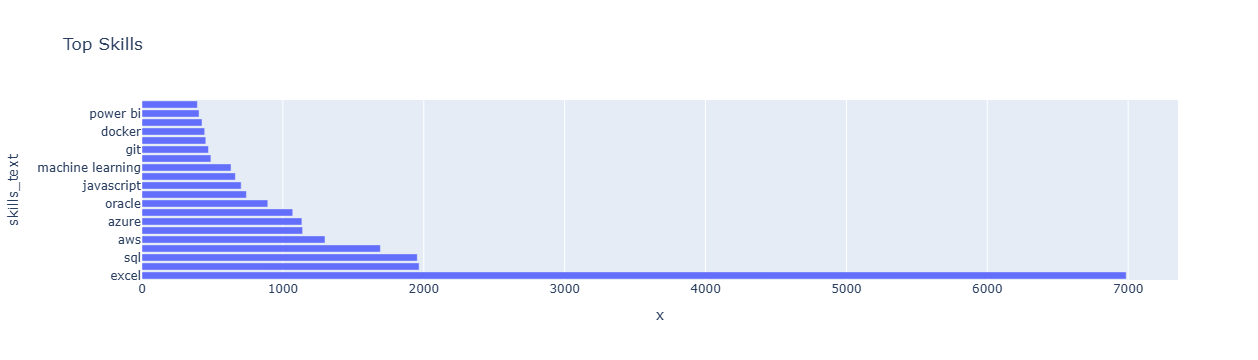

In [18]:
fig = px.bar(
    top_skills,
    x=top_skills.values,
    y=top_skills.index,
    orientation="h",
    title="Top Skills"
)

fig.show()

In [20]:
#Entreprises qui recrutent
top_companies = jobs.company.value_counts().head(20)

top_companies

company
Liberty Healthcare and Rehabilitation Services    1059
unknown                                            844
The Job Network                                    505
Lowe's Companies, Inc.                             368
TEKsystems                                         334
J. Galt                                            308
CareerStaff Unlimited                              278
Capital One                                        253
Solomon Page                                       232
Petco                                              200
Insight Global                                     198
Life Care Centers of America                       190
Wells Fargo                                        178
Ingersoll Rand                                     173
MedPro Healthcare Staffing                         159
TravelNurseSource                                  158
Talentify.io                                       155
H&R Block                                          152
Vo

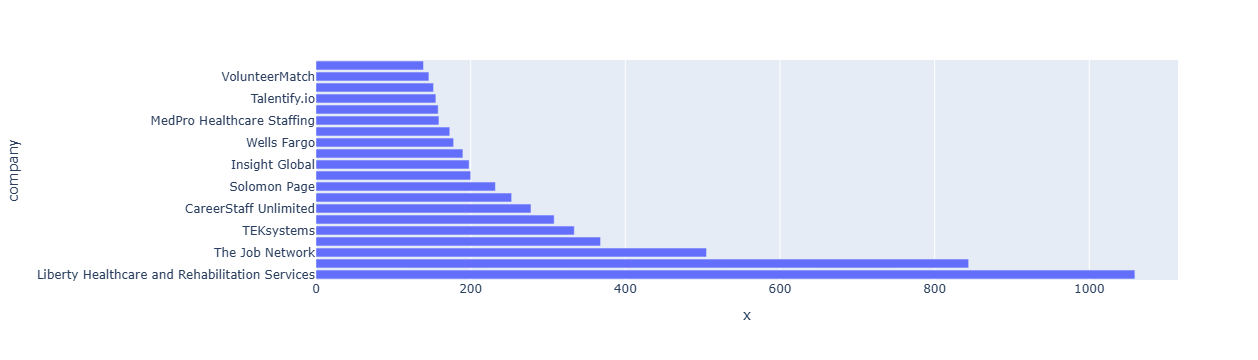

In [21]:
fig = px.bar(
    top_companies,
    x=top_companies.values,
    y=top_companies.index,
    orientation="h"
)

fig.show()

In [22]:
#Localisations
jobs.location.value_counts().head(20)

location
United States                      3265
New York, NY                       1047
Houston, TX                         744
Chicago, IL                         718
Dallas, TX                          550
Atlanta, GA                         513
Los Angeles, CA                     430
Charlotte, NC                       417
Boston, MA                          416
Phoenix, AZ                         414
Austin, TX                          400
New York City Metropolitan Area     356
Washington, DC                      351
San Francisco, CA                   336
Seattle, WA                         320
San Diego, CA                       318
Denver, CO                          303
Philadelphia, PA                    262
Tampa, FL                           247
San Antonio, TX                     244
Name: count, dtype: int64

In [23]:
#Salaires
jobs.salary.describe()

count    1.443100e+04
mean     1.857899e+05
std      5.435239e+06
min      0.000000e+00
25%      5.200000e+04
50%      8.112000e+04
75%      1.248000e+05
max      5.356000e+08
Name: salary, dtype: float64

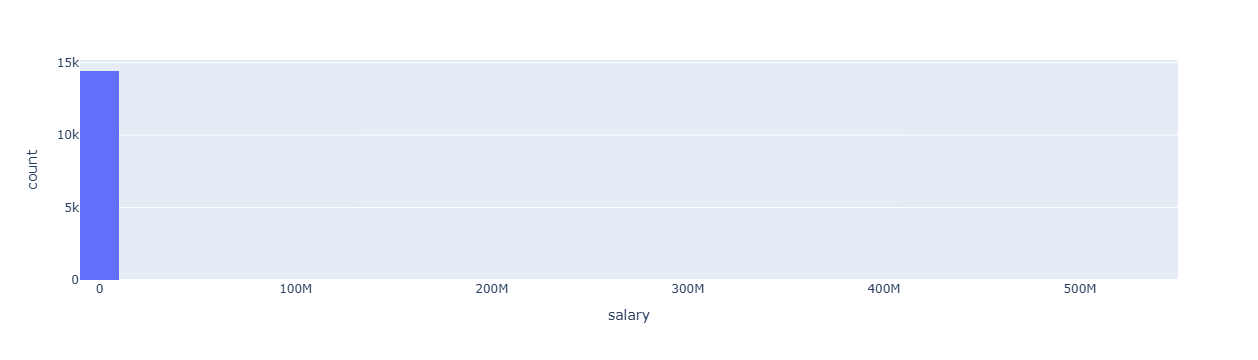

In [24]:
fig = px.histogram(
    jobs,
    x="salary",
    nbins=40
)

fig.show()

<Axes: >

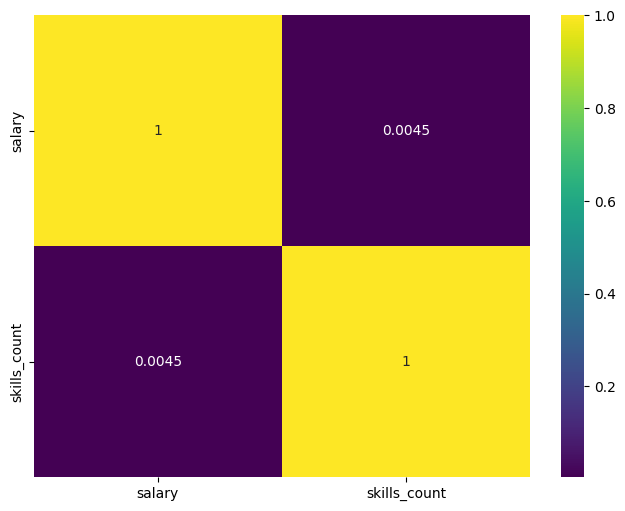

In [26]:
#Corrélation
import seaborn as sns
import matplotlib.pyplot as plt

corr = jobs.select_dtypes("number").corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="viridis"
)

In [27]:
#Sauvegarder un rapport
from pathlib import Path

REPORTS = Path("../reports")
REPORTS.mkdir(exist_ok=True)

top_skills.to_csv(
    REPORTS / "Top_Skills.csv",
    index=True
)

print("Top Skills sauvegardé.")

Top Skills sauvegardé.


In [28]:
top_jobs.to_csv(
    REPORTS / "Top_Jobs.csv",
    index=True
)

print("Top Jobs sauvegardé.")

Top Jobs sauvegardé.


In [29]:
top_companies.to_csv(
    REPORTS / "Top_Companies.csv",
    index=True
)

print("Top Companies sauvegardé.")

Top Companies sauvegardé.


In [30]:
pip install reportlab


   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 399.6 kB/s eta 0:00:04
   ---------- ----------------------------- 0.5/2.0 MB 399.6 kB/s eta 0:00:04
   ---------- ----------------------------- 0.5/2.0 MB 399.6 kB/s eta 0:00:04
   ---------------- ----------------------- 0.8/2.0 MB 435.8 kB/s eta 0:00:03
   ---------------- ----------------------- 0.8/2.0 MB 435.8 kB/s eta 0:00:03
   --------------------- ------------------ 1.0/2.0 MB 488.8 kB/s eta 0:00:02
   --------------------- ------------------ 1.0/

In [32]:
#Créer un rapport PDF
from reportlab.platypus import SimpleDocTemplate
from reportlab.platypus import Paragraph
from reportlab.lib.styles import getSampleStyleSheet

styles = getSampleStyleSheet()

doc = SimpleDocTemplate("../reports/EDA_Report.pdf")

story = []

story.append(
    Paragraph("JobPulse AI - Rapport EDA", styles["Heading1"])
)

story.append(
    Paragraph(f"Nombre d'offres : {len(jobs)}", styles["Normal"])
)

story.append(
    Paragraph(f"Nombre de métiers : {jobs.job_title.nunique()}", styles["Normal"])
)

story.append(
    Paragraph(f"Nombre d'entreprises : {jobs.company.nunique()}", styles["Normal"])
)

story.append(
    Paragraph(f"Nombre de compétences : {skills.nunique()}", styles["Normal"])
)

doc.build(story)

print("Rapport PDF créé.")

Rapport PDF créé.
